In [ ]:
import torch
import time
# import numpy as np
from torchvision.io import read_video
from matplotlib import pyplot as plt
import matplotlib.patches as patches

# from api import Pytorch_RetinaFace
from api2 import crop_with_centers_scales, FaceAlignment, get_preds_fromhm
idx = 8
vid = read_video('./ltxv_cropped.mp4', output_format="TCHW")[0][0:idx]
centers = torch.tensor([
        [411.1799, 486.2936],
        [410.5586, 486.6238],
        [409.8705, 486.2303],
        [409.8454, 485.6248],
        [407.1741, 483.3664],
        [403.5238, 479.6957],
        [401.3889, 475.5485],
        [398.5702, 471.6290]], device="cuda")[0:idx]
scales = torch.tensor([2.1871, 2.1685, 2.1784, 2.1396, 2.1041, 2.1295, 2.1493, 2.1434], device="cuda")[0:idx]

c:\venv\TorchStandard\Lib\site-packages\torchvision\io\_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
c:\venv\TorchStandard\Lib\site-packages\torchvision\io\video.py:199: UserWarning: The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.
  warnings.warn("The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.")


In [ ]:
with torch.no_grad():
    # Le modèle prédira toujours des points meme sur une image totalement noire
    # Donc inutile de mettre des protections ici
    fa = FaceAlignment(device="cuda", face_detector="retina")

    inp = vid.to(device="cuda", dtype=torch.float32)
    inp.div_(255.0)
    out = fa.face_alignment_net(inp) #TCHW float32
    pts = get_preds_fromhm(out)

Using device: cuda
Loading pretrained model from ./detection/retina/weights/mobilenet0.25_Final.pth
remove prefix 'module.'
Missing keys:0
Unused checkpoint keys:0
Used keys:300
preds shape: torch.Size([8, 68, 2]), preds_orig shape: torch.Size([8, 68, 2])
preds shape: torch.Size([8, 68, 2]), preds_orig shape: torch.Size([8, 68, 2])


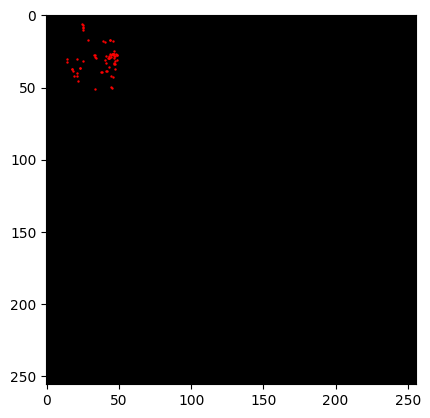

In [20]:
display_idx = 7
plt.imshow(vid[display_idx].permute(1, 2 ,0).numpy()/255)
ld = pts[display_idx].cpu().numpy()
xs, ys = ld[:, 0], ld[:, 1]
plt.scatter(xs, ys, c='red', marker='.', s=2)